# Project Title : Spotify Customer Churn Anaysis

# Domain : Social Media

#Objective
1) To identify meaningful patterns, trends, and insights from the dataset using exploratory data analysis (EDA)
2) To clean, transform, and preprocess the data for analysis
3) To create meaningful visualizations that clearly explain the story behind the data
4) To provide actionable insights and recommendations from the analysis

# Outcome
The project helps uncover key patterns, trends, and hidden insights from the dataset. The analysis provides a clear understanding of the data and supports decision-making with evidence-based findings.

# Dataset Information
Source : https://www.kaggle.com/datasets/nabihazahid/spotify-dataset-for-churn-analysis/data

Year : Data collected during 2025

Description : The dataset contains Spotify user information, including demographics, listening behavior, subscription type, and device usage, with the goal of predicting whether a user will churn or remain active.

user_id → Unique identifier for each user

gender → User gender (Male/Female/Other)

age → User age

country → User location

subscription_type → Type of Spotify subscription (Free, Premium, Family, Student)

listening_time → Minutes spent listening per day

songs_played_per_day → Number of songs played daily

skip_rate → Percentage of songs skipped

device_type → Device used (Mobile, Desktop, Web)

ads_listened_per_week → Number of ads heard per week

offline_listening → Offline mode usage

is_churned → Target variable (0 = Active, 1 = Churned)

Dataset Type: Mixed (numeric + categorical)

#Type of Analysis

Prescriptive Analysis (recommendations for business decisions)

# Stage 1 – Problem Definition and Dataset Selection

The main purpose of this dataset is to study customer churn — which means finding out which users might stop using or cancel their Spotify Premium subscription.
Studying churn is important for Spotify and similar apps because:

(1) Getting new users costs a lot of money.

(2) The company earns money only if users stay subscribed.

(3) The more users listen, the more valuable they become.

(4) To stay ahead of other apps, Spotify needs to give users better suggestions and reasons to keep using the app.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

from google.colab import files
uploaded = files.upload()

Saving spotify_churn_dataset.csv to spotify_churn_dataset.csv


In [ ]:
# Import the dataset into Python (using pandas)
df = pd.read_csv("spotify_churn_dataset.csv")
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [ ]:
# Checking for any missing values.
df.isnull().sum()

,0
user_id,0
gender,0
age,0
country,0
subscription_type,0
listening_time,0
songs_played_per_day,0
skip_rate,0
device_type,0
ads_listened_per_week,0


In [ ]:
# Initial EDA
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,8000.0,4000.500000,2309.545410,1.0,2000.75,4000.5,6000.25,8000.0
age,8000.0,37.662125,12.740359,16.0,26.00,38.0,49.00,59.0
listening_time,8000.0,154.068250,84.015596,10.0,81.00,154.0,227.00,299.0
songs_played_per_day,8000.0,50.127250,28.449762,1.0,25.00,50.0,75.00,99.0
skip_rate,8000.0,0.300127,0.173594,0.0,0.15,0.3,0.45,0.6
ads_listened_per_week,8000.0,6.943875,13.617953,0.0,0.00,0.0,5.00,49.0
offline_listening,8000.0,0.747750,0.434331,0.0,0.00,1.0,1.00,1.0
is_churned,8000.0,0.258875,0.438044,0.0,0.00,0.0,1.00,1.0


In [ ]:
# Number of rows and columns in the dataset
rows=df.shape[0]
print("Number of rows is :",rows)
columns=df.shape[1]
print("Number of columns is :",columns)

Number of rows is : 8000
Number of columns is : 12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


## Stage 2 – Data Cleaning and Pre-processing

In [ ]:
# Checking for duplicates and deleting those duplicates
df.duplicated().sum()
df = df.drop_duplicates()

In [ ]:
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


In [ ]:
# Changing skipping rate column from decimal to percentage
df["skip_rate"] = df["skip_rate"] * 100
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,20.0,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,34.0,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,4.0,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,31.0,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,36.0,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,30.0,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,59.0,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,33.0,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,27.0,Desktop,0,1,0


In [ ]:
# converting the data type of user ID column
df["user_id"]=df["user_id"].astype(object)

Stage 3 – EDA and Visualizations

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

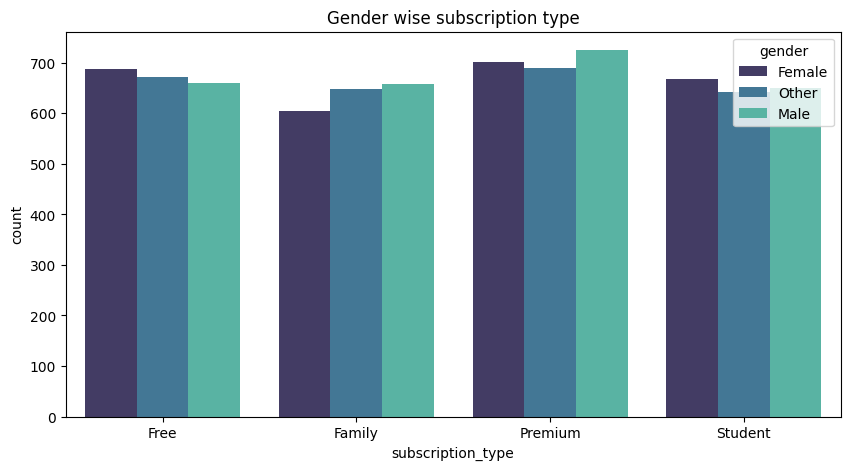

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="subscription_type",hue="gender",palette="mako")
plt.title("Gender wise subscription type")
plt.show()

This chart shows us Gender wise subscription type. In this case we have Male, Female and other. We have four type of subscriptions like Free, Family, Premium and Student. This countplot shows the frequency of different categories in a single categorical variable. Here in first case, Female customer opted more for free and student subscription whereas more number of male customer opted for Family sybscription and Premium subscription.

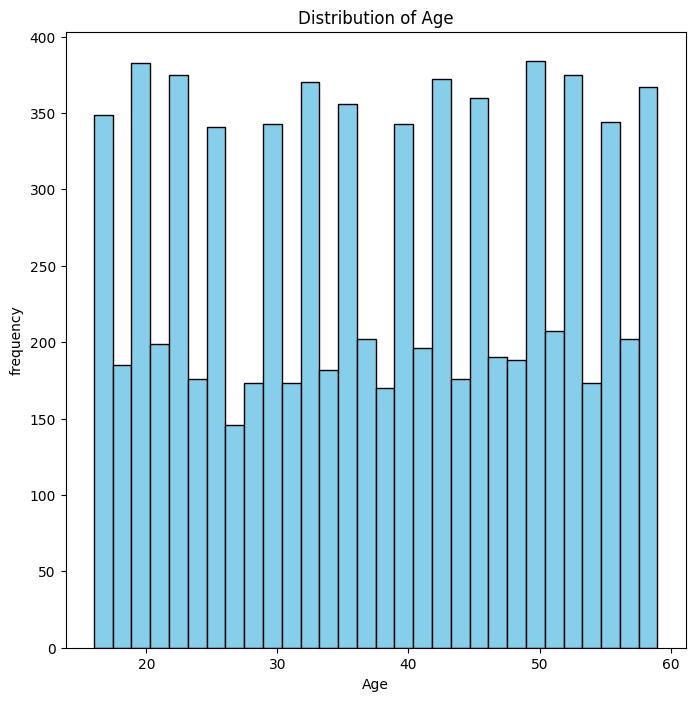

In [ ]:
plt.figure(figsize=(8,8))
plt.hist(df['age'],bins=30,color='skyblue',edgecolor='black')
plt.xlabel('Age')
plt.ylabel('frequency')
plt.title('Distribution of Age')
plt.show()

Here x-axis represents the age and y-axis represents the frequency. The bars are almost same in height. So the age are uniformly distributed. The users are evenly spread across all age groups. No single age range dominates the dataset. Therefore, age doesn't influence churn or listening behaviour.

<Figure size 1500x1000 with 0 Axes>

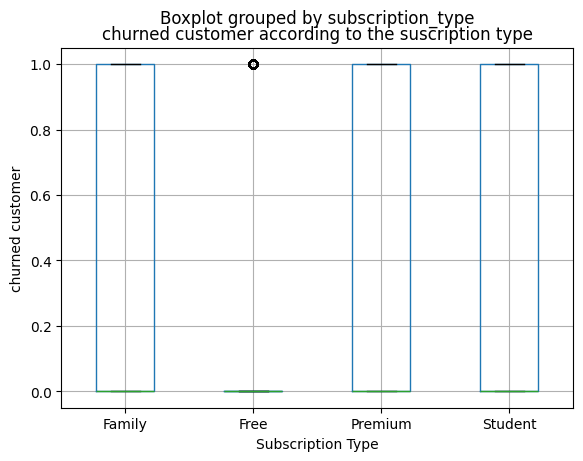

In [ ]:
plt.figure(figsize=(15,10))
df.boxplot(column='is_churned', by='subscription_type')
plt.title('churned customer according to the suscription type')
plt.xlabel('Subscription Type')
plt.ylabel('churned customer')
plt.show()

Most of the data for each subscription type is at 0 (Active) meaning the majority of users across all plans are still active. The few 1’s (Churned) appear as outliers, indicating a small number of users have churned in each plan. The Free plan shows a slightly more visible outlier (1.0), meaning a few more churned users compared to other subscription types. Premium and Family plans seem to have the least churn, possibly because paying or shared users are more engaged.


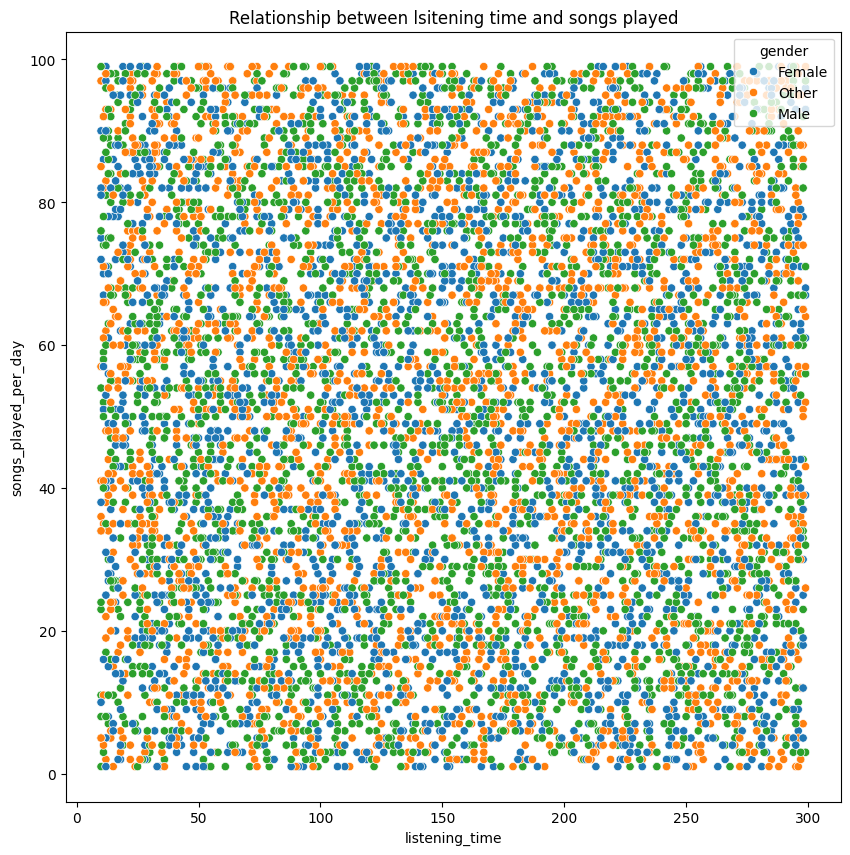

In [ ]:
plt.figure(figsize=(10,10))
sns.scatterplot(x='listening_time',y='songs_played_per_day',data=df,hue='gender')
plt.xlabel('listening_time')
plt.ylabel('songs_played_per_day')
plt.title('Relationship between lsitening time and songs played')
plt.show()

This scatter plot shows the relationship between listening_time (x-axis) and songs_played_per_day (y-axis), with different colors representing gender.
However, the points are highly scattered without a clear pattern. There is no strong relationship (correlation) between how long users listen and how many songs they play per day.Users with short listening time and users with long listening time can both have high or low number of songs played.The points are spread almost uniformly, indicating users have very diverse listening behavior.Gender does not form clear clusters, meaning listening habits don’t differ much across genders.

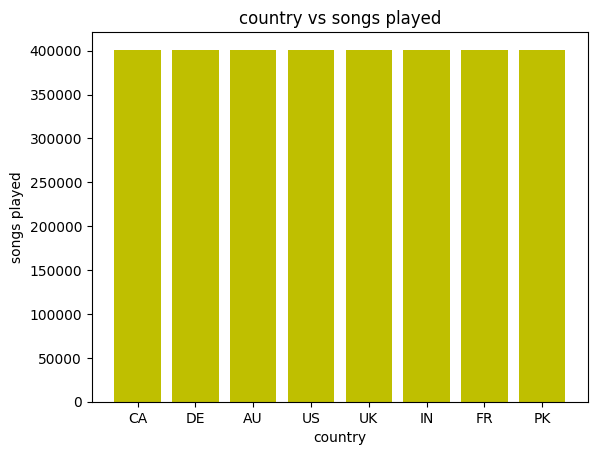

In [ ]:
plt.bar(df['country'],df['songs_played_per_day'].sum(),color='y',linewidth=1)
plt.xlabel('country')
plt.ylabel('songs played')
plt.title('country vs songs played')
plt.show()

The total number of songs played is very similar across every country shown (CA, DE, AU, US, UK, IN, FR, PK). There is no noticeable difference in music streaming activity between these countries based on this dataset. This suggests that users in all countries are playing songs in roughly equal amounts.

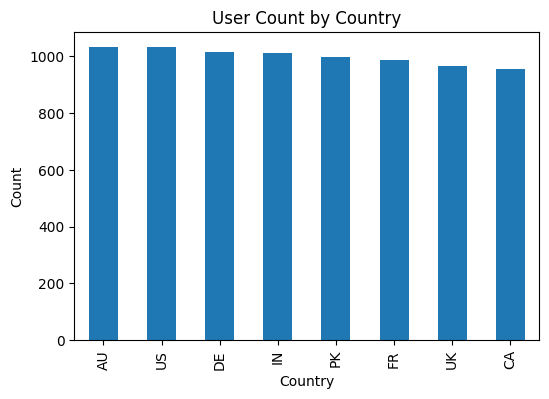

In [ ]:
plt.figure(figsize=(6,4))
df['country'].value_counts().plot(kind='bar')
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("User Count by Country")
plt.show()

This bar plot shows the number of users in ech country. By looking at the graph US has the highest number of users. And all other countries does not much differ from the te highest count. Spotify has approximately equal number of users in all countries.

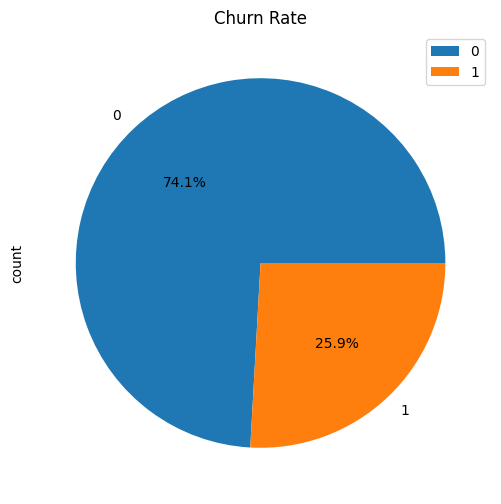

In [ ]:
plt.figure(figsize=(6,6))
df['is_churned'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Churn Rate")
plt.legend()
plt.show()

74.1% (blue, labeled 0) : These customers did NOT churn. They continued using the service.

 25.9% (orange, labeled 1) :  These customers churned. They stopped using the service.

 A majority of users are still active. However, about 1 out of 4 users are leaving, which is a significant churn rate.Retention is good, but there is room for improvement. The company should analyze why 25.9% of users are leaving. This could involve checking:
1. Subscription cost issues

2. Lack of user engagement

3. Customer satisfaction problems

4. Competitor influence

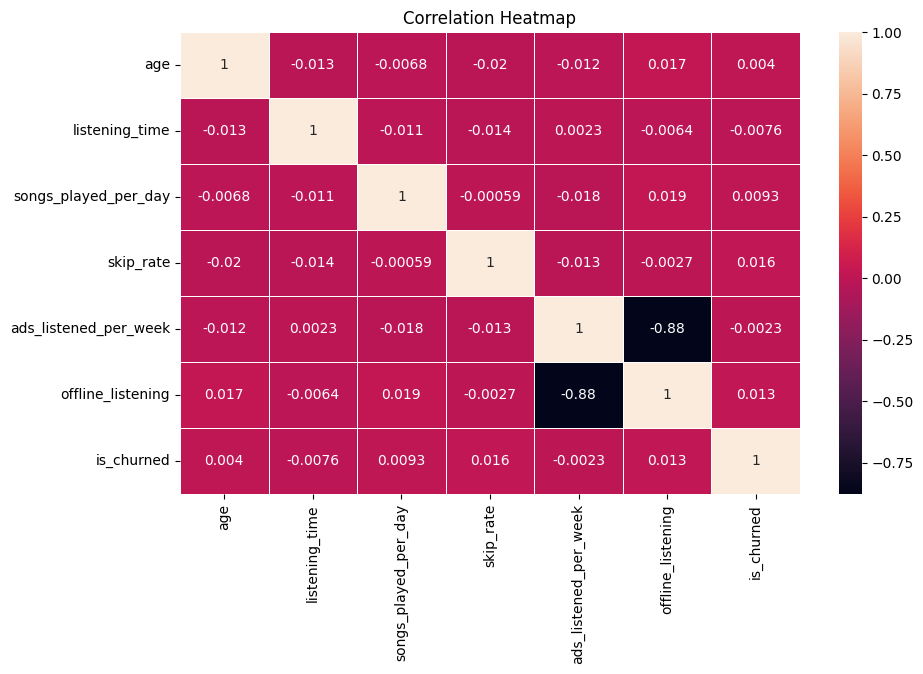

In [ ]:
numeric_cols = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

This heatmap shows how strongly each variable in your dataset is related to the others. The correlation values range from -1 to +1:

+1 → Perfect positive relationship (as one increases, the other increases).

-1 → Perfect negative relationship (as one increases, the other decreases).

0 → No meaningful relationship.

1. Very strong negative correlation

ads_listened_per_week and offline_listening → -0.88

This means users who listen offline tend to hear very few ads. Users who don’t use offline mode hear more ads.This makes logical sense: offline listening usually requires a paid subscription → fewer ads.

2. Almost all other correlations are very weak. Most values are close to 0 (like -0.02, 0.01, etc.), meaning age, listening time, skip rate, songs played per day do not strongly relate to each other.

3. Churn (is_churned) has very weak correlation with all variables
Example: is_churned vs listening_time = -0.0076 → extremely weak.
This means no single variable strongly predicts churn by itself.So churn is likely influenced by multiple factors together, not just one behavior.

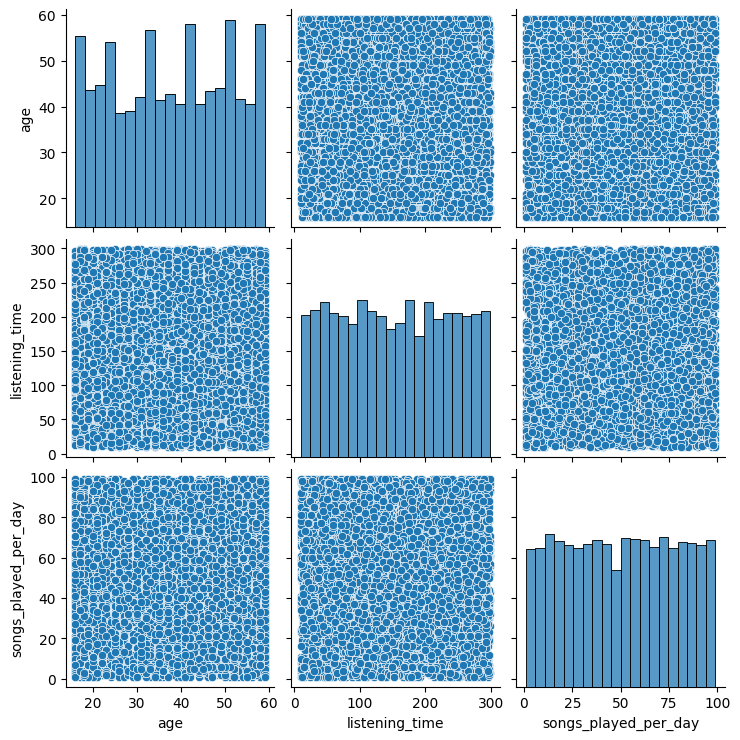

In [ ]:
sns.pairplot(df[['age','listening_time','songs_played_per_day','subscription_type']])
plt.show()


age vs listening_time : No clear relationship

age vs songs_played_per_day: No clear relationship

listening_time vs songs_played_per_day : Slight but not strong positive spread, but still mostly random

All histograms :	Variables are evenly spread .No major skew or unusual distribution

Since these variables do not correlate strongly, it suggests:

User behavior is varied and does not follow simple linear patterns.

Predicting churn will require combining multiple features, not just relying on one.

This confirms what we saw in the correlation heatmap earlier.

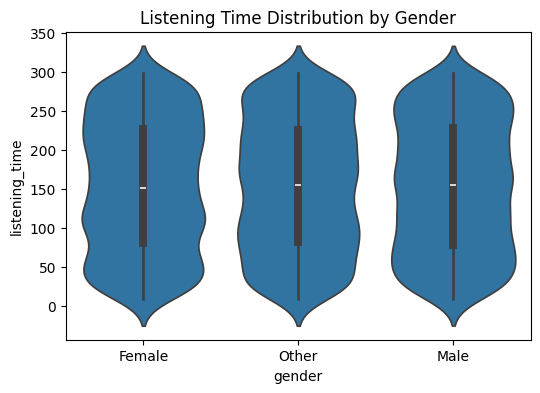

In [ ]:
plt.figure(figsize=(6,4))
sns.violinplot(x='gender', y='listening_time', data=df)
plt.title("Listening Time Distribution by Gender")
plt.show()

This violin plot shows how listening time is distributed across different gender groups—Female, Male, and Other. The shapes of the violins are very similar, indicating that listening behavior is largely the same regardless of gender. All three groups have a similar range of listening times, from very low usage up to around 300 minutes, and the median listening time for each group is also nearly identical, sitting around the middle of that range. This suggests that no particular gender listens significantly more or less than the others. In other words, gender does not appear to be a strong factor influencing how much time users spend listening on the platform.

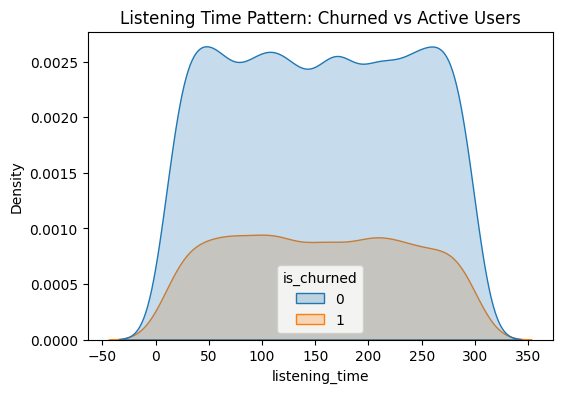

In [ ]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x='listening_time', hue='is_churned', fill=True)
plt.title("Listening Time Pattern: Churned vs Active Users")
plt.show()

This chart compares the listening time patterns of churned and active users. The blue area represents active users (is_churned = 0), while the orange line represents churned users (is_churned = 1). From the graph, we can see that active users generally have higher listening times, indicated by a broader and taller density curve. In contrast, churned users have lower listening times with a smaller density curve. This suggests that users who spend less time listening are more likely to churn, whereas consistent and longer listening activity is associated with user retention.

In [ ]:
from google.colab import files
df.to_csv('spotify_churn_dataset.csv', index=False)
files.download('spotify_churn_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Stage 4 – Documentation, Insights and Presentation

https://drive.google.com/file/d/1Q6Fpc4h9FOhSu40WkUJQUdacVBW-H0Wf/view?usp=sharing

FUTURE ENHANCEMENT :

Begin by exploring overall user distribution, showing the mix of free vs. premium users and key demographic segments. This helps identify the platform’s core audience.

Next move into engagement behavior that is listening hours, session counts, and device usage. These charts make it clear that high engagement is the strongest driver of retention, while irregular or low listening patterns are early indicators of churn.

The dashboard then highlights the churn breakdown. Here, the patterns come together: the users most likely to churn are typically free-plan users, low-engagement listeners, and specific demographic groups.

Finally, the last section of the dashboard converts insight into action. It shows which segments are high-value, which user groups need urgent attention, and what behavior changes precede churn. By following the insights from this dashboard, the business can strategically reduce churn, improve user experience, and grow long-term revenue.


CONCLUSION :

The more people use the app, the more likely they are to stay. The less they use it, the more likely they are to leave. So the business should focus on keeping users active and improving the experience for free and low-engagement users.